# Solution Outcome

This notebook shows how to use the solution package, and also demonstrates its limitation.

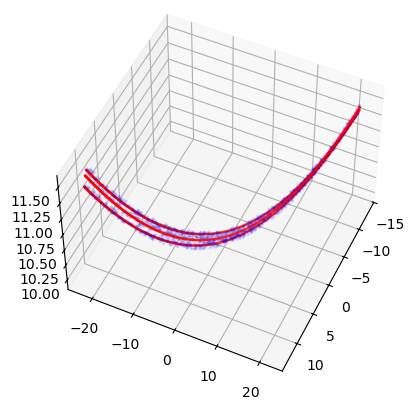

In [2]:
from solution import fit, plot_fitted_curve
from research import read_dataset, DIFFICULTIES
import matplotlib.pyplot as plt

# Go with the extrahard dataset
data = read_dataset(DIFFICULTIES[3])

fit_results = fit(data)

ax = plt.figure().add_subplot(projection="3d")

# Draw the original points
ax.scatter(data["x"], data["y"], data["z"], c = "blue", alpha = 0.1, s = 2)

# Draw the fitted curves
for result in fit_results:
    plot_fitted_curve(ax, result)

ax.view_init(elev=50, azim=25)
plt.show()

## Limitation

The clustering method used in this solution assumes that all wires follow a similar overall direction. As a result, it can fail when some wires run in different directions. The example below illustrates a case where the clustering method does not perform well. It grouped the wires into two clusters rather than six.

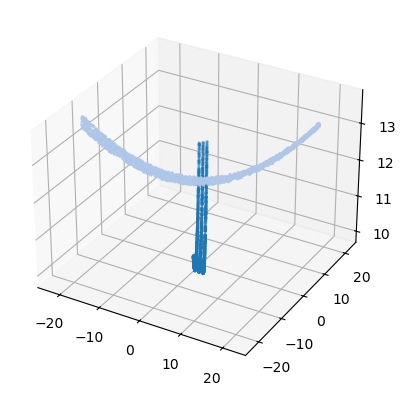

In [3]:
import pandas as pd
import numpy as np
from research.colors import get_color
from solution.cluster import cluster_hdbscan

# Use the easy dataset as example
data = read_dataset(DIFFICULTIES[0])

# Rotate the curves and lift them up by 2
up_curves = data.copy()

x_new = up_curves["y"]
y_new = -up_curves["x"]
up_curves["x"] = x_new
up_curves["y"] = y_new

up_curves["z"] += 2

data = pd.concat([data, up_curves])


ax = plt.figure().add_subplot(projection="3d")

labels = cluster_hdbscan(data)
colors = np.array([get_color(label) for label in labels])


# Draw the original points
ax.scatter(data["x"], data["y"], data["z"], c = colors, s = 2)

plt.show()